# Эксперименты: ансамблевые методы и ассоциативные правила

Перебор гиперпараметров, Random Forest, GBM, XGBoost, Apriori / FP-Growth.

In [51]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import shap

from src.preprocessing import (
    load_raw_data, filter_region, create_binary_target,
    get_Xy, split_data, binarize_features,
    FEATURES, TARGET_REG, TARGET_CLF,
)
from src.modeling import (
    train_random_forest, train_gbm, train_xgboost_regressor,
    find_association_rules, regression_metrics, save_model,
)

plt.rcParams["figure.dpi"] = 110

In [52]:
raw = load_raw_data("../data/raw/Доходы домохозяйств_2023.xlsx")
df = filter_region(raw)
df, q3 = create_binary_target(df)

X, y_clf = get_Xy(df, FEATURES, TARGET_CLF)
X_train, X_test, y_train, y_test = split_data(X, y_clf, stratify=y_clf)

X_reg, y_reg = get_Xy(df, FEATURES, TARGET_REG)
X_tr_reg, X_te_reg, y_tr_reg, y_te_reg = split_data(X_reg, y_reg)

## Перебор гиперпараметров

Систематически проверяем ключевые параметры для классификации и регрессии.

In [53]:
# Random Forest: перебор max_depth
rf_search = []
for n_est in [50, 100, 200]:
    for depth in [1, 2, 3, 5, None]:
        rf = RandomForestClassifier(n_estimators=n_est, max_depth=depth, random_state=42)
        rf.fit(X_train, y_train)
        rf_search.append({
            "n_estimators": n_est,
            "max_depth": str(depth),
            "Accuracy test": accuracy_score(y_test, rf.predict(X_test)),
            "ROC-AUC test": roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
        })

rf_search_df = pd.DataFrame(rf_search).sort_values("ROC-AUC test", ascending=False)
print("Random Forest — перебор гиперпараметров (топ-10):")
rf_search_df.head(10).to_string(index=False)

Random Forest — перебор гиперпараметров (топ-10):


' n_estimators max_depth  Accuracy test  ROC-AUC test\n           50      None       0.982472      0.997573\n          100      None       0.981595      0.997532\n          200      None       0.981595      0.997479\n           50         5       0.971954      0.995591\n          200         5       0.971954      0.995469\n          100         5       0.972831      0.995325\n           50         3       0.943032      0.990314\n          200         3       0.937774      0.989726\n          100         3       0.941280      0.989478\n           50         2       0.929886      0.977466'

In [54]:
rf_search_df.head(10)

,n_estimators,max_depth,Accuracy test,ROC-AUC test
4,50,None,0.982472,0.997573
9,100,None,0.981595,0.997532
14,200,None,0.981595,0.997479
3,50,5,0.971954,0.995591
13,200,5,0.971954,0.995469
8,100,5,0.972831,0.995325
2,50,3,0.943032,0.990314
12,200,3,0.937774,0.989726
7,100,3,0.941280,0.989478
1,50,2,0.929886,0.977466


In [55]:
# GBM: перебор learning_rate и max_depth
gbm_search = []
for lr in [0.01, 0.05, 0.1, 0.2]:
    for depth in [1, 2, 3]:
        gbm = GradientBoostingClassifier(n_estimators=100, max_depth=depth, learning_rate=lr, random_state=42)
        gbm.fit(X_train, y_train)
        gbm_search.append({
            "learning_rate": lr,
            "max_depth": depth,
            "Accuracy test": accuracy_score(y_test, gbm.predict(X_test)),
            "ROC-AUC test": roc_auc_score(y_test, gbm.predict_proba(X_test)[:, 1]),
        })

gbm_search_df = pd.DataFrame(gbm_search).sort_values("ROC-AUC test", ascending=False)
print("GBM — перебор гиперпараметров:")
gbm_search_df

GBM — перебор гиперпараметров:


,learning_rate,max_depth,Accuracy test,ROC-AUC test
8,0.10,3,0.981595,0.996624
11,0.20,3,0.982472,0.996545
10,0.20,2,0.982472,0.996165
5,0.05,3,0.977213,0.995866
7,0.10,2,0.978089,0.995778
4,0.05,2,0.961437,0.994294
9,0.20,1,0.957932,0.992189
6,0.10,1,0.948291,0.985325
2,0.01,3,0.936897,0.979937
3,0.05,1,0.933392,0.975560


In [56]:
# XGBoost: перебор max_depth
import xgboost as xgb

xgb_search = []
for depth in [2, 3, 5, 7, 10]:
    model = xgb.XGBRegressor(n_estimators=100, max_depth=depth, learning_rate=0.1, random_state=42)
    model.fit(X_tr_reg, y_tr_reg)
    y_pred = model.predict(X_te_reg)
    xgb_search.append({
        "max_depth": depth,
        "R² test": r2_score(y_te_reg, y_pred),
        "RMSE test": mean_squared_error(y_te_reg, y_pred) ** 0.5,
        "MAE test": mean_absolute_error(y_te_reg, y_pred),
    })

xgb_search_df = pd.DataFrame(xgb_search).sort_values("R² test", ascending=False)
print("XGBoost — перебор max_depth:")
xgb_search_df

XGBoost — перебор max_depth:


,max_depth,R² test,RMSE test,MAE test
3,7,0.866425,26767.253609,7327.563135
4,10,0.858783,27522.335520,6794.883563
2,5,0.854631,27923.972800,8925.547875
1,3,0.831111,30098.299608,11355.171200
0,2,0.776791,34601.695798,15445.409131


In [57]:
# Сводная таблица всех экспериментов
best_rf  = rf_search_df.iloc[0]
best_gbm = gbm_search_df.iloc[0]
best_xgb = xgb_search_df.iloc[0]

print(f"Лучший RF:  n_estimators={best_rf['n_estimators']}, max_depth={best_rf['max_depth']}, ROC-AUC={best_rf['ROC-AUC test']:.4f}")
print(f"Лучший GBM: lr={best_gbm['learning_rate']}, max_depth={best_gbm['max_depth']}, ROC-AUC={best_gbm['ROC-AUC test']:.4f}")
print(f"Лучший XGB: max_depth={best_xgb['max_depth']}, R²={best_xgb['R² test']:.4f}")

Лучший RF:  n_estimators=50, max_depth=None, ROC-AUC=0.9976
Лучший GBM: lr=0.1, max_depth=3.0, ROC-AUC=0.9966
Лучший XGB: max_depth=7.0, R²=0.8664


## Random Forest (max_depth=2, сравнение с GBM)

Запускаем с `max_depth=2` — тот же уровень сложности, что и у GBM, чтобы сравнение было честным. Оптимальный конфиг из поиска — `max_depth=None`, ROC-AUC=0.998 — приведён в таблице выше.

In [58]:
rf_result = train_random_forest(X_train, X_test, y_train.values, y_test.values)

print(f"Accuracy  train={rf_result['train_accuracy']:.4f}, test={rf_result['test_accuracy']:.4f}")
print(f"ROC-AUC   train={rf_result['train_roc_auc']:.4f}, test={rf_result['test_roc_auc']:.4f}")
print("\nConfusion matrix (test):")
print(rf_result["test_cm"])
print("\nClassification report (test):")
print(rf_result["test_report"])

Accuracy  train=0.9256, test=0.9308
ROC-AUC   train=0.9786, test=0.9765

Confusion matrix (test):
[[833  23]
 [ 56 229]]

Classification report (test):
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       856
           1       0.91      0.80      0.85       285

    accuracy                           0.93      1141
   macro avg       0.92      0.89      0.90      1141
weighted avg       0.93      0.93      0.93      1141



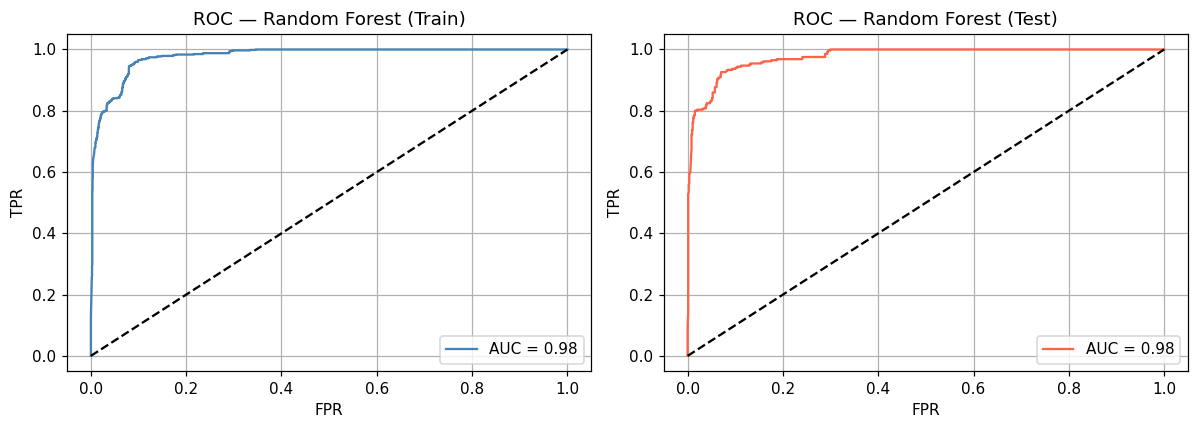

In [59]:
rf_model = rf_result["model"]
y_tr_prob_rf = rf_model.predict_proba(X_train)[:, 1]
y_te_prob_rf = rf_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_true, y_prob, split, color in zip(
    axes, [y_train.values, y_test.values], [y_tr_prob_rf, y_te_prob_rf],
    ["Train", "Test"], ["steelblue", "tomato"],
):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, label=f"AUC = {rf_result[f'{split.lower()}_roc_auc']:.2f}")
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC — Random Forest ({split})")
    ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig("../report/images/rf_roc.png", bbox_inches="tight")
plt.show()

In [60]:
print("MDI:")
print(rf_result["feature_importance_mdi"])

mda = permutation_importance(rf_model, X_test, y_test.values, n_repeats=15, random_state=42)
print("\nMDA:")
print(pd.Series(mda.importances_mean, index=X_train.columns).sort_values(ascending=False))

MDI:
rasq       0.579982
chlico     0.157921
rasress    0.149449
potras     0.081124
chdet      0.031524
dtype: float64

MDA:
rasq       0.239907
rasress    0.021209
chlico     0.001169
potras     0.000351
chdet     -0.000584
dtype: float64


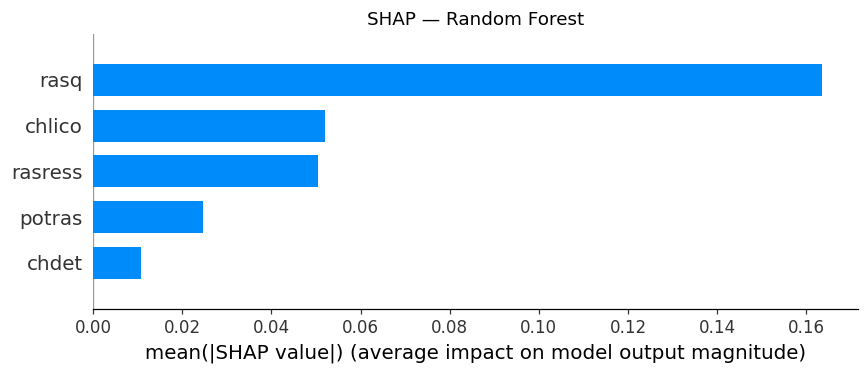

In [61]:
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)
shap.summary_plot(shap_values_rf[..., 1], X_test, plot_type="bar", show=False)
plt.title("SHAP — Random Forest")
plt.tight_layout()
plt.savefig("../report/images/rf_shap.png", bbox_inches="tight")
plt.show()

In [62]:
save_model(rf_model, "random_forest")

PosixPath('models/random_forest.pkl')

RF: Accuracy = 0.93, ROC-AUC = 0.98. Ключевой признак по всем методам — `rasq`.

## Градиентный бустинг (GBM)

In [63]:
gbm_result = train_gbm(X_train, X_test, y_train.values, y_test.values)

print(f"Accuracy  train={gbm_result['train_accuracy']:.4f}, test={gbm_result['test_accuracy']:.4f}")
print(f"ROC-AUC   train={gbm_result['train_roc_auc']:.4f}, test={gbm_result['test_roc_auc']:.4f}")
print("\nConfusion matrix (test):")
print(gbm_result["test_cm"])
print("\nClassification report (test):")
print(gbm_result["test_report"])

Accuracy  train=0.9823, test=0.9781
ROC-AUC   train=0.9973, test=0.9958

Confusion matrix (test):
[[847   9]
 [ 16 269]]

Classification report (test):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       856
           1       0.97      0.94      0.96       285

    accuracy                           0.98      1141
   macro avg       0.97      0.97      0.97      1141
weighted avg       0.98      0.98      0.98      1141



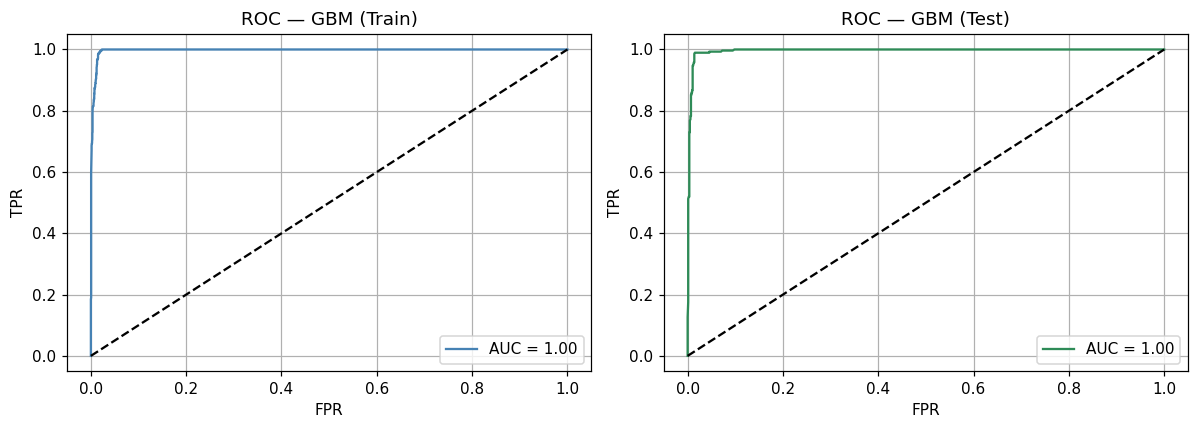

In [64]:
gbm_model = gbm_result["model"]
y_tr_prob_gbm = gbm_model.predict_proba(X_train)[:, 1]
y_te_prob_gbm = gbm_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_true, y_prob, split, color in zip(
    axes, [y_train.values, y_test.values], [y_tr_prob_gbm, y_te_prob_gbm],
    ["Train", "Test"], ["steelblue", "seagreen"],
):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, label=f"AUC = {gbm_result[f'{split.lower()}_roc_auc']:.2f}")
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC — GBM ({split})")
    ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig("../report/images/gbm_roc.png", bbox_inches="tight")
plt.show()

In [65]:
print("MDI:")
print(gbm_result["feature_importance_mdi"])

mda_gbm = permutation_importance(gbm_model, X_test, y_test.values, n_repeats=10, random_state=42)
print("\nMDA:")
print(pd.Series(mda_gbm.importances_mean, index=X_train.columns).sort_values(ascending=False))

MDI:
rasq       0.762193
rasress    0.192543
chlico     0.033198
potras     0.012065
chdet      0.000000
dtype: float64

MDA:
rasress    0.267835
chlico     0.223576
rasq       0.080280
potras     0.005784
chdet      0.000000
dtype: float64


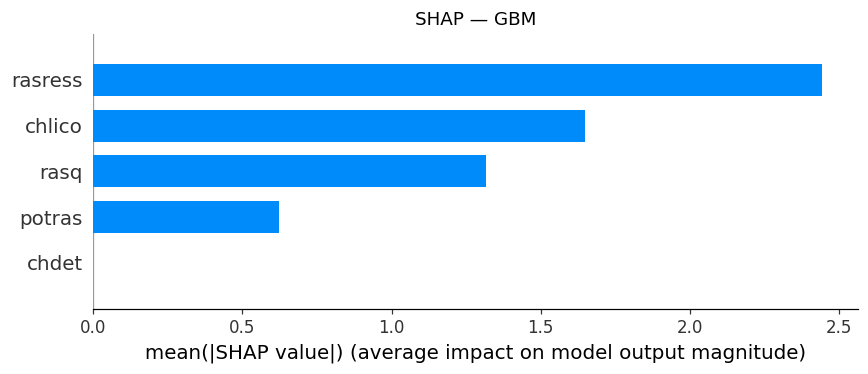

In [66]:
explainer_gbm = shap.Explainer(gbm_model, X_train)
shap_values_gbm = explainer_gbm(X_test)
shap.summary_plot(shap_values_gbm.values, X_test, plot_type="bar", show=False)
plt.title("SHAP — GBM")
plt.tight_layout()
plt.savefig("../report/images/gbm_shap.png", bbox_inches="tight")
plt.show()

In [67]:
save_model(gbm_model, "gbm")

PosixPath('models/gbm.pkl')

GBM: Accuracy = 0.978, ROC-AUC = 0.996 — лучшая модель классификации.

## Сравнение классификаторов

In [68]:
clf_summary = pd.DataFrame([
    {"Модель": "Logistic (baseline, без RFE)", "Accuracy": 0.934, "ROC-AUC": 0.984, "F1 (класс 1)": "—"},
    {"Модель": "KNN k=5 (baseline)",           "Accuracy": 0.970, "ROC-AUC": 0.991, "F1 (класс 1)": "—"},
    {"Модель": "Logistic + RFE",               "Accuracy": 0.961, "ROC-AUC": 0.988, "F1 (класс 1)": 0.92},
    {"Модель": "Random Forest",                "Accuracy": rf_result["test_accuracy"],  "ROC-AUC": rf_result["test_roc_auc"],  "F1 (класс 1)": 0.85},
    {"Модель": "GBM",                          "Accuracy": gbm_result["test_accuracy"], "ROC-AUC": gbm_result["test_roc_auc"], "F1 (класс 1)": 0.96},
])
clf_summary

,Модель,Accuracy,ROC-AUC,F1 (класс 1)
0,"Logistic (baseline, без RFE)",0.934000,0.984000,—
1,KNN k=5 (baseline),0.970000,0.991000,—
2,Logistic + RFE,0.961000,0.988000,0.92
3,Random Forest,0.930762,0.976498,0.85
4,GBM,0.978089,0.995778,0.96


## XGBoost: регрессия среднедушевого дохода

In [69]:
xgb_result = train_xgboost_regressor(X_tr_reg, X_te_reg, y_tr_reg.values, y_te_reg.values)

print("XGBoost:")
print(f"R²   train={xgb_result['train_r2']:.4f}, test={xgb_result['test_r2']:.4f}")
print(f"RMSE train={xgb_result['train_rmse']:,.0f}, test={xgb_result['test_rmse']:,.0f}")
print(f"MAE  train={xgb_result['train_mae']:,.0f}, test={xgb_result['test_mae']:,.0f}")

XGBoost:
R²   train=0.9980, test=0.8664
RMSE train=6,297, test=26,767
MAE  train=3,702, test=7,328


In [70]:
linreg = LinearRegression().fit(X_tr_reg, y_tr_reg)
lin_metrics = regression_metrics(y_tr_reg.values, linreg.predict(X_tr_reg), y_te_reg.values, linreg.predict(X_te_reg))

reg_summary = pd.DataFrame([
    {"Модель": "LinearRegression (baseline)", "R²": lin_metrics["test_r2"], "RMSE": lin_metrics["test_rmse"], "MAE": lin_metrics["test_mae"]},
    {"Модель": "XGBoost",                    "R²": xgb_result["test_r2"],  "RMSE": xgb_result["test_rmse"],  "MAE": xgb_result["test_mae"]},
])
reg_summary

,Модель,R²,RMSE,MAE
0,LinearRegression (baseline),0.755282,36230.486368,25703.842489
1,XGBoost,0.866425,26767.253609,7327.563135


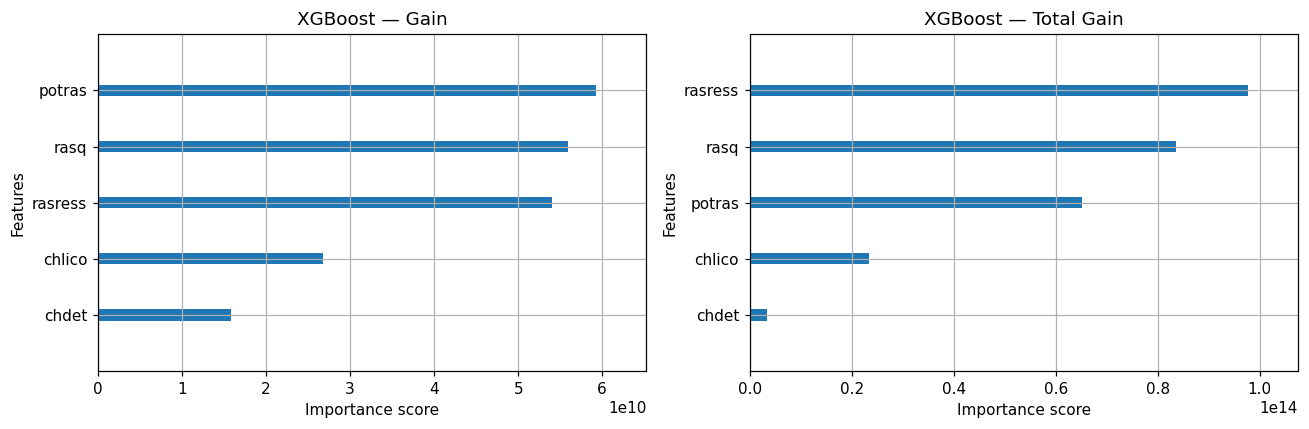

In [71]:
from xgboost import plot_importance

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_importance(xgb_result["model"], importance_type="gain",       ax=axes[0], show_values=False)
plot_importance(xgb_result["model"], importance_type="total_gain", ax=axes[1], show_values=False)
axes[0].set_title("XGBoost — Gain")
axes[1].set_title("XGBoost — Total Gain")
plt.tight_layout()
plt.savefig("../report/images/xgb_feature_importance.png", bbox_inches="tight")
plt.show()

In [72]:
save_model(xgb_result["model"], "xgboost_regressor")

PosixPath('models/xgboost_regressor.pkl')

XGBoost (R² = 0.87) на 11% лучше по R², MAE в 3.5 раза ниже линейной регрессии.

## Ассоциативные правила (Apriori и FP-Growth)

In [73]:
df_assoc = df[FEATURES + [TARGET_REG]].dropna().copy()
df_bin = binarize_features(df_assoc, FEATURES + [TARGET_REG])

rules_apriori = find_association_rules(df_bin, method="apriori",  min_support=0.05, min_confidence=0.5)
rules_fp      = find_association_rules(df_bin, method="fpgrowth", min_support=0.05, min_confidence=0.5)

print(f"Apriori: {len(rules_apriori)} правил, FP-Growth: {len(rules_fp)} правил")
rules_fp[["antecedents", "consequents", "support", "confidence", "lift"]].head(8)

Apriori: 296 правил, FP-Growth: 296 правил


,antecedents,consequents,support,confidence,lift
0,"frozenset({rasress_high, chdet_high, doxodn_hi...","frozenset({rasq_high, chlico_high})",0.102814,0.744762,5.294074
1,"frozenset({rasq_high, chlico_high})","frozenset({rasress_high, chdet_high, doxodn_hi...",0.102814,0.730841,5.294074
2,"frozenset({doxodn_high, potras_high, chlico_hi...","frozenset({rasq_high, rasress_high, chdet_high})",0.102814,0.671821,5.267910
3,"frozenset({rasq_high, rasress_high, chdet_high})","frozenset({doxodn_high, potras_high, chlico_hi...",0.102814,0.806186,5.267910
4,"frozenset({rasq_high, rasress_high, chlico_high})","frozenset({doxodn_high, chdet_high, potras_high})",0.102814,0.730841,5.166150
5,"frozenset({rasq_high, chlico_high})","frozenset({doxodn_high, chdet_high, potras_high})",0.102814,0.730841,5.166150
6,"frozenset({doxodn_high, chdet_high, potras_high})","frozenset({rasq_high, chlico_high})",0.102814,0.726766,5.166150
7,"frozenset({doxodn_high, chdet_high, potras_high})","frozenset({rasq_high, rasress_high, chlico_high})",0.102814,0.726766,5.166150


In [74]:
def rule_set_to_str(s):
    return ", ".join(sorted(str(x) for x in s))

with open("../data/processed/association_rules.txt", "w", encoding="utf-8") as f:
    for method, rules in [("Apriori", rules_apriori), ("FP-Growth", rules_fp)]:
        f.write(f"\n=== {method} ===\n\n")
        for _, row in rules.head(50).iterrows():
            f.write(
                f"IF [{rule_set_to_str(row['antecedents'])}] "
                f"THEN [{rule_set_to_str(row['consequents'])}]; "
                f"sup={row['support']:.3f}, conf={row['confidence']:.3f}, lift={row['lift']:.2f}\n"
            )

Apriori и FP-Growth дают идентичные топ-правила — это подтверждает устойчивость найденных паттернов.

## Итоговое сравнение

In [75]:
print("Классификация (тест):")
print(clf_summary.to_string(index=False))

print("\nРегрессия (тест):")
print(reg_summary.to_string(index=False))

Классификация (тест):
                      Модель  Accuracy  ROC-AUC F1 (класс 1)
Logistic (baseline, без RFE)  0.934000 0.984000            —
          KNN k=5 (baseline)  0.970000 0.991000            —
              Logistic + RFE  0.961000 0.988000         0.92
               Random Forest  0.930762 0.976498         0.85
                         GBM  0.978089 0.995778         0.96

Регрессия (тест):
                     Модель       R²         RMSE          MAE
LinearRegression (baseline) 0.755282 36230.486368 25703.842489
                    XGBoost 0.866425 26767.253609  7327.563135
